# SafeStreet AI - Model Training

## Objective

Train the SafeStreet AI Risk Prediction model using the processed dataset.

### Input
- processed_crime.parquet

### Output
- safestreet_rf_v1.joblib

### Model
- Random Forest Classifier (Baseline)

In [1]:
# ==========================================
# Imports
# ==========================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

import joblib

In [2]:
# ==========================================
# Experiment Configuration
# ==========================================

# Dataset
USE_SAMPLE = True
SAMPLE_SIZE = 1_000_000

# Split
TEST_SIZE = 0.20
RANDOM_STATE = 42

# Model
N_ESTIMATORS = 100
N_JOBS = -1

# Output
MODEL_NAME = "safestreet_rf_v1"

print("Configuration Loaded Successfully")

Configuration Loaded Successfully


In [3]:
# ==========================================
# Load Processed Dataset
# ==========================================

DATA_PATH = Path("../data/processed/processed_crime.parquet")

df = pd.read_parquet(DATA_PATH)

print("Dataset Shape:", df.shape)

print(df.columns.tolist())

print("RiskLevel exists:", "RiskLevel" in df.columns)

df.head()

Dataset Shape: (7758698, 10)
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area', 'Location Description', 'RiskLevel']
RiskLevel exists: True


,Latitude,Longitude,Hour,DayOfWeek,Month,IsWeekend,District,Community Area,Location Description,RiskLevel
0,41.813999,-87.598138,18,3,9,0,2.0,39.0,RESIDENCE,Low
1,41.954584,-87.648376,22,5,9,1,19.0,3.0,STREET,Low
2,41.808521,-87.626066,1,6,9,1,2.0,38.0,VACANT LOT/LAND,High
3,41.885759,-87.713588,2,6,9,1,11.0,27.0,SIDEWALK,High
4,41.947100,-87.662116,2,6,9,1,19.0,6.0,SIDEWALK,Low


In [4]:
from pathlib import Path

print(DATA_PATH.resolve())

D:\SOUMIT MANNA\IEM\Internship\Summer Internship\SafeStreet\ml_backend\data\processed\processed_crime.parquet


In [5]:
print(df.columns)

Index(['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend',
       'District', 'Community Area', 'Location Description', 'RiskLevel'],
      dtype='str')


In [6]:
# ==========================================
# Create Development Sample
# ==========================================

from sklearn.model_selection import train_test_split

if USE_SAMPLE:

    train_df, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        stratify=df["RiskLevel"],
        random_state=RANDOM_STATE
    )

else:
    train_df = df.copy()

print("Training Dataset Shape:", train_df.shape)

print()

print(train_df["RiskLevel"].value_counts(normalize=True).mul(100).round(2))

Training Dataset Shape: (1000000, 10)

RiskLevel
Low       58.53
High      29.61
Medium    11.87
Name: proportion, dtype: float64


In [7]:
print(df.columns.tolist())

['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area', 'Location Description', 'RiskLevel']


In [8]:
# ==========================================
# Dataset Verification
# ==========================================

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7758698 entries, 0 to 7758697
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Latitude              float64
 1   Longitude             float64
 2   Hour                  int32  
 3   DayOfWeek             int32  
 4   Month                 int32  
 5   IsWeekend             int64  
 6   District              float64
 7   Community Area        float64
 8   Location Description  str    
 9   RiskLevel             str    
dtypes: float64(4), int32(3), int64(1), str(2)
memory usage: 614.0 MB
None


In [9]:
print(df.shape)
print(df.columns.tolist())

(7758698, 10)
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area', 'Location Description', 'RiskLevel']


## Feature Selection

Create the feature matrix (**X**) and target variable (**y**) for model training.

In [18]:
FEATURES = [
    # Original Features
    "Latitude",
    "Longitude",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "District",
    "Community Area",
    "Location Description",

    # Feature Engineering V2
    "TimeOfDay",
    "IsNight",
    "IsBusinessHours",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos",
]

TARGET = "RiskLevel"

X = train_df[FEATURES]
print(f"Number of Features: {len(FEATURES)}")
print("\nFeatures:")
for feature in FEATURES:
    print("-", feature)
y = train_df[TARGET]

KeyError: "['TimeOfDay', 'IsNight', 'IsBusinessHours', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos'] not in index"

## Feature Types

Separate numerical and categorical features for preprocessing.

In [11]:
# ==========================================
# Identify Feature Types
# ==========================================

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['Location Description']

Numerical Features
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area']


## Train Test Split

Split the dataset into training and testing subsets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (800000, 9)
Testing Set  : (200000, 9)


In [13]:
# ==========================================
# Verify Class Distribution
# ==========================================

print("Training Distribution")

print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print()

print("Testing Distribution")

print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training Distribution
RiskLevel
Low       58.53
High      29.61
Medium    11.87
Name: proportion, dtype: float64

Testing Distribution
RiskLevel
Low       58.53
High      29.61
Medium    11.87
Name: proportion, dtype: float64


Preprocessing Pipeline

In [15]:
# ==========================================
# Build Preprocessing Pipeline
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Latitude', 'Longitude', 'Hour', 'DayOfWeek',
                                  'Month', 'IsWeekend', 'District',
                                  'Community Area']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Location Description'])])


Model Pipeline

In [16]:
# ==========================================
# Build Random Forest Pipeline
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=N_ESTIMATORS,
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ),
        ),
    ]
)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'Hour', 'DayOfWeek', 'Month',
                                                   'IsWeekend', 'District',
                                                   'Community Area']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
    

Model Training

In [24]:
# ==========================================
# Train Random Forest Model
# ==========================================

import time

print("=" * 60)
print("Training SafeStreet AI Model...")
print("=" * 60)

start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {training_time:.2f} seconds")
print(f"Training Time : {training_time/60:.2f} minutes")

Training SafeStreet AI Model...

Training Completed Successfully!
Training Time : 1643.04 seconds
Training Time : 27.38 minutes


Model Evaluation

In [25]:
# ==========================================
# Evaluate Model
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

print("=" * 60)
print("Evaluating Model...")
print("=" * 60)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Evaluating Model...

Accuracy : 0.5964
Accuracy : 59.64%

Classification Report

              precision    recall  f1-score   support

        High       0.49      0.36      0.42     59211
         Low       0.64      0.81      0.72    117053
      Medium       0.37      0.11      0.17     23736

    accuracy                           0.60    200000
   macro avg       0.50      0.43      0.43    200000
weighted avg       0.56      0.60      0.56    200000


Confusion Matrix

[[21522 36495  1194]
 [18621 95189  3243]
 [ 3885 17286  2565]]


Save Model

In [26]:
# ==========================================
# Save Trained Model
# ==========================================

from pathlib import Path
import joblib

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "safestreet_rf_v1.joblib"

joblib.dump(model, model_path)

print("Model saved successfully!")
print(f"Location: {model_path.resolve()}")

Model saved successfully!
Location: D:\SOUMIT MANNA\IEM\Internship\Summer Internship\SafeStreet\ml_backend\saved_models\safestreet_rf_v1.joblib


Confusion Matrix Visualization

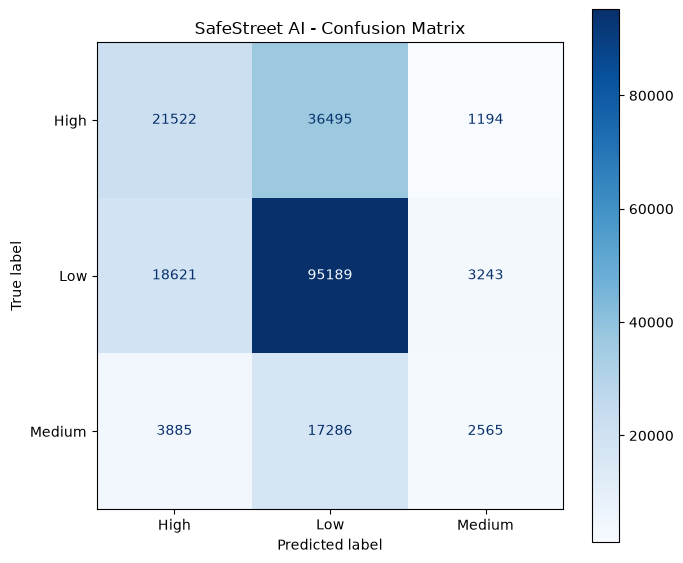

In [27]:
# ==========================================
# Confusion Matrix Heatmap
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)

plt.title("SafeStreet AI - Confusion Matrix")
plt.tight_layout()
plt.show()

Feature Importance

In [17]:
# ==========================================
# Feature Importance
# ==========================================

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(20)

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# ==========================================
# Top 20 Feature Importance
# ==========================================

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()

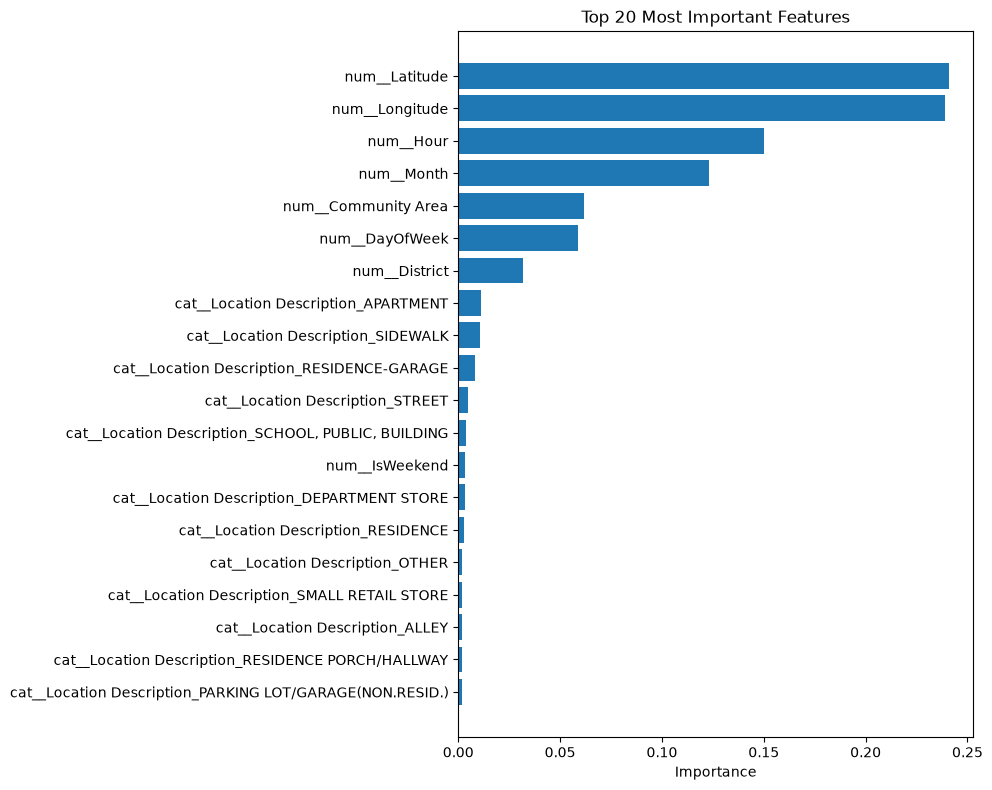

In [29]:
# ==========================================
# Top 20 Feature Importance
# ==========================================

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()

Model Metadata

In [30]:
# ==========================================
# Save Model Metadata
# ==========================================

import json
from datetime import datetime

metadata = {
    "model_name": "SafeStreet Random Forest v1",
    "algorithm": "RandomForestClassifier",
    "dataset": "dev_sample.parquet",
    "training_samples": len(X_train),
    "testing_samples": len(X_test),
    "features": FEATURES,
    "target": TARGET,
    "accuracy": round(float(accuracy), 4),
    "training_time_seconds": round(training_time, 2),
    "training_time_minutes": round(training_time / 60, 2),
    "random_state": RANDOM_STATE,
    "n_estimators": N_ESTIMATORS,
    "created_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

metadata_path = MODEL_DIR / "safestreet_rf_v1_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully!")
print(metadata_path.resolve())

Metadata saved successfully!
D:\SOUMIT MANNA\IEM\Internship\Summer Internship\SafeStreet\ml_backend\saved_models\safestreet_rf_v1_metadata.json


In [31]:
# ==========================================
# Final Model Summary
# ==========================================

print("=" * 70)
print("SafeStreet AI - Baseline Model Summary")
print("=" * 70)

print(f"Model                 : SafeStreet Random Forest v1")
print(f"Algorithm             : Random Forest")
print(f"Training Samples      : {len(X_train):,}")
print(f"Testing Samples       : {len(X_test):,}")
print(f"Number of Features    : {len(FEATURES)}")
print(f"Accuracy              : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Training Time         : {training_time/60:.2f} minutes")
print(f"Saved Model           : {model_path.name}")

print("=" * 70)
print("Baseline Model Completed Successfully!")
print("=" * 70)

SafeStreet AI - Baseline Model Summary
Model                 : SafeStreet Random Forest v1
Algorithm             : Random Forest
Training Samples      : 800,000
Testing Samples       : 200,000
Number of Features    : 9
Accuracy              : 0.5964 (59.64%)
Training Time         : 27.38 minutes
Saved Model           : safestreet_rf_v1.joblib
Baseline Model Completed Successfully!


# ==========================================
# Historical Feature Engineering
# ==========================================

## V3.1 Community Area Historical Risk Features